In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from datetime import datetime

In [46]:
file_path = 'NEW__ RFQ US Rates - Bonds Only (July - Sept 24) - Blockhouse.xlsx'
df = pd.read_excel(file_path)
df

,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,SettlementDays,SettlementDate,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket
0,2024-09-30,66FA7D45432800D20002,Client8,Done,OFFTHERUN,100000000,100000000,100000000,100000000,100000000,...,1,2024-10-01,T+1,2024-09-30 06:28:00,2024-09-30 06:28:00,1,0.03,50+M,5-7 YR,5y-7y
1,2024-09-30,TRSY_20240930_15961,Client9,Done,"OFFTHERUN,DOUBLEOLDS",2100000,2100000,2100000,2100000,2100000,...,1,2024-10-01,T+1,2024-09-30 16:00:00,2024-09-30 16:00:00,1,0.95,1-5M,7-10 YR,7y-10y
2,2024-09-30,TRSY_20240930_314,Client9,Done,ONTHERUN,53000000,53000000,53000000,53000000,53000000,...,1,2024-10-01,T+1,2024-09-30 15:46:00,2024-09-30 15:46:00,1,0.07,50+M,7-10 YR,7y-10y
3,2024-09-30,66FAEA57432800020001,Client41,Done,OFFTHERUN,500000,500000,500000,500000,500000,...,1,2024-10-01,T+1,2024-09-30 14:14:00,2024-09-30 14:14:00,1,0.03,500K-1M,0-1 YR,<18mos
4,2024-09-30,66FAC35D455C00210006,Client139,Done,OFFTHERUN,1058000,1058000,1058000,1058000,1058000,...,1,2024-10-01,T+1,2024-09-30 11:27:00,2024-09-30 11:27:00,1,0.03,1-5M,5-7 YR,3y-5y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40825,2024-07-01,E682EBF3454C00010001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 13:48:00,2024-07-01 13:50:00,1,0.03,10-25M,5-7 YR,3y-5y
40826,2024-07-01,E682D1C745CC000A0001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 11:56:00,2024-07-01 11:58:00,1,0.06,25-50M,5-7 YR,3y-5y
40827,2024-07-01,E682C785454C00010001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 11:13:00,2024-07-01 11:14:00,1,0.03,25-50M,5-7 YR,3y-5y
40828,2024-07-01,E682AFF2454C000C0001,Client736,CustomerTimeOut,"OFFTHERUN,DOUBLEOLDS",0,0,0,0,0,...,1,2024-07-02,T+1,2024-07-01 09:32:00,2024-07-01 09:34:00,1,0.04,10-25M,5-7 YR,3y-5y


In [47]:
df = df[::-1]
df = df.reset_index(drop=True)

df = df[df["InstrumentSubGroup"] == "OFFTHERUN"]

In [48]:
missing_values = df.isnull().sum()
missing_values[:20]

EventDate                  0
Id                         0
Client                     0
RFQStatus                  0
InstrumentSubGroup         0
Mkt Traded Vol             0
Market Traded Vol (USD)    0
Our Traded Vol             0
Our Traded Vol (USD)       0
TiedWonVol                 0
Num of Dealers             0
Trader                     0
Sales                      0
Covered Vol                0
ActionStr                  0
Tier                       0
InstrumentCode             0
InstrumentDescription      0
AssetClass                 0
Market                     0
dtype: int64

In [49]:
missing_values[20:]

LegNo                         0
Maturity Date                 0
RFQNumberOfQuotes             0
Buy/Sell                      0
Best Bid Price                0
Mid Price                     0
Best Ask Price                0
Deal Value                    0
AwayFromMid                   0
TickIdentifier               27
Deal Spread                   0
Cover                         0
CoverPnL                      0
SettlementDays                0
SettlementDate                0
SettlementStops               0
RFQ CreateTime                0
RFQ ClosedTime                0
AnAutoReplyRFQs               0
First Response Time (Sec)     0
TradeSizeBucket               0
Sector                        0
MaturityBucket                0
dtype: int64

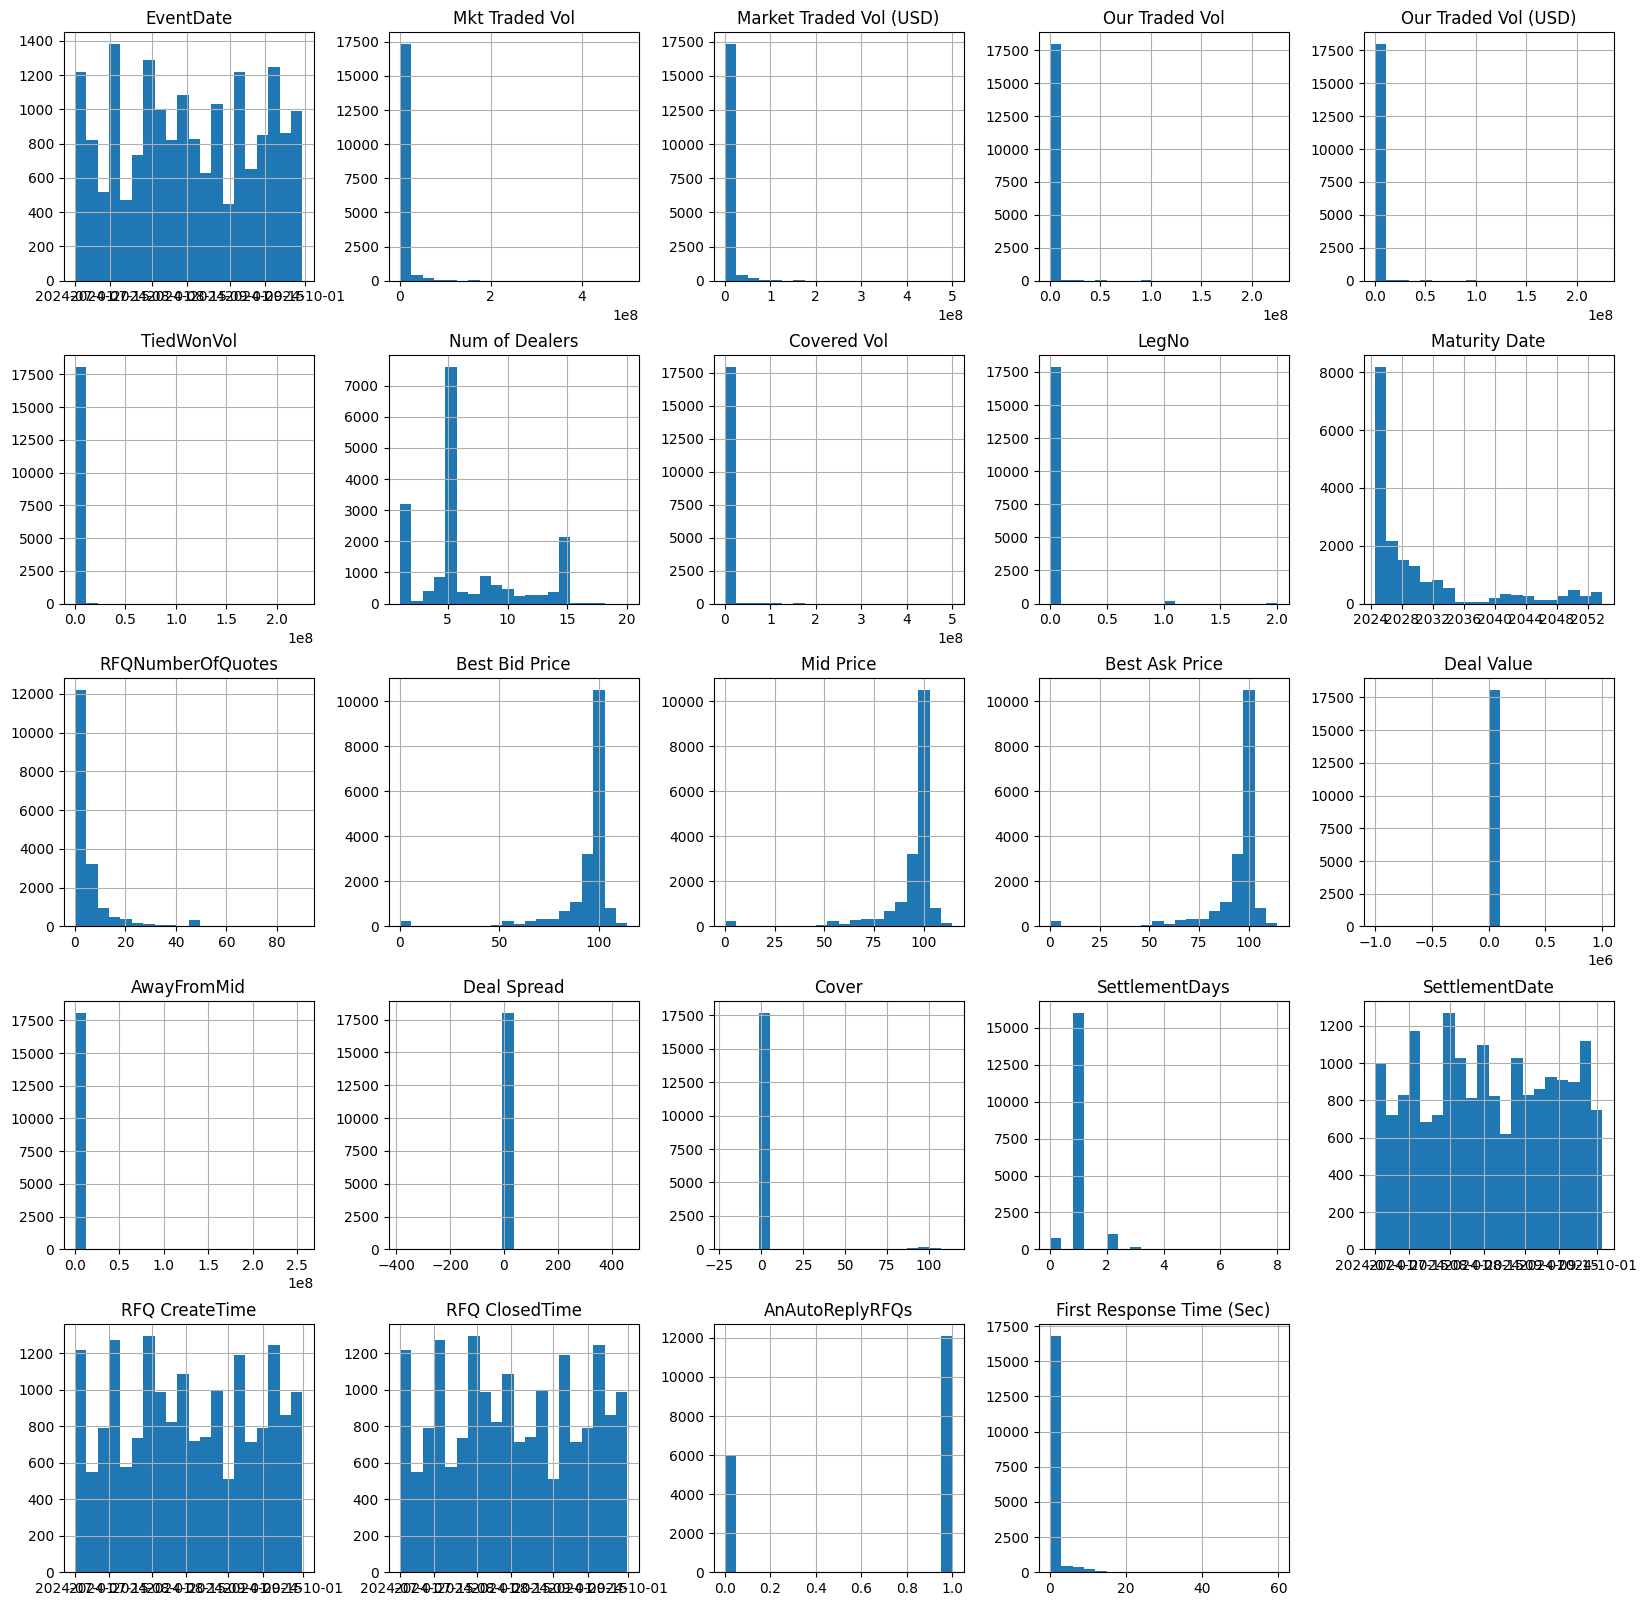

In [50]:
df.hist(bins=20, figsize=(20,20))
plt.show()

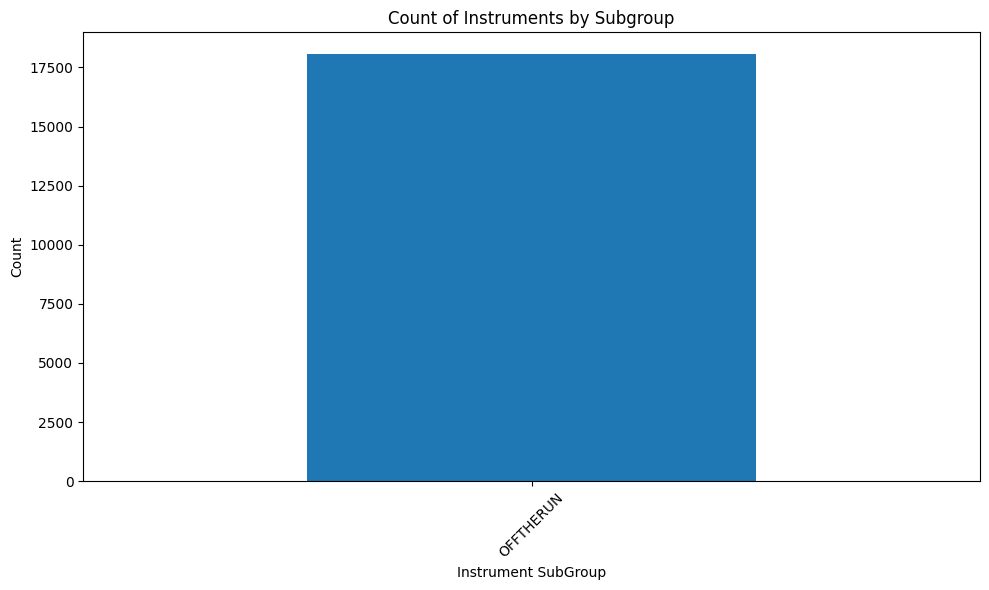

In [51]:
subgroup_counts = df['InstrumentSubGroup'].value_counts()

# Plot the bar chart
plt.figure(figsize=(10, 6))
subgroup_counts.plot(kind='bar')
plt.title('Count of Instruments by Subgroup')
plt.xlabel('Instrument SubGroup')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
subgroup_counts = df['Maturity Date'].value_counts()
subgroup_counts

Maturity Date
2025-07-31    446
2025-06-30    405
2025-03-31    404
2025-02-15    402
2025-08-31    393
             ... 
2024-07-15     12
2045-08-15     11
2027-06-15     10
2045-05-15      9
2031-06-30      3
Name: count, Length: 211, dtype: int64

In [53]:
subgroup_counts = df['MaturityBucket'].value_counts()
subgroup_counts

MaturityBucket
<18mos    8456
10-30y    2832
3y-5y     2151
7y-10y    1401
2y-3y     1212
5y-7y     1172
18m-2y     857
Name: count, dtype: int64

In [54]:
subgroup_counts = df['Sector'].value_counts()
subgroup_counts

Sector
0-1 YR      7507
5-7 YR      2732
15-30 YR    2630
2-3 YR      2157
7-10 YR     1626
3-5 YR      1196
10-15 YR     202
HCPN          26
TIPS           5
Name: count, dtype: int64

In [55]:
df['Trader'].nunique()

9

In [56]:
subgroup_counts = df['SettlementDate'].value_counts()
subgroup_counts

SettlementDate
2024-09-03    444
2024-10-01    434
2024-08-06    431
2024-08-01    428
2024-09-04    384
             ... 
2024-08-26    193
2024-09-10    168
2024-10-02     51
2024-07-01     17
2024-10-03      3
Name: count, Length: 67, dtype: int64

In [57]:
df['Client'].nunique()

629

## On-the-run VPIN

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# Set the rolling window size
n = 10  # for 10-day rolling VPIN

df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})

# Create lists to store Client names and mean VPIN values
client_names = []
mean_vpin_values = []

# Loop through each trader to calculate daily VPIN
for trader in df['Client'].unique():
    tmp_df = df[df["Client"] == trader]

    # Step 1: Aggregate daily buy and sell volumes based on the Sign
    daily_volume = tmp_df.groupby([tmp_df['EventDate'].dt.date, 'Sign'])['Market Traded Vol (USD)'].sum().unstack(fill_value=0)
    daily_volume = daily_volume.rename(columns={1: 'Buy Volume', -1: 'Sell Volume'})

    # Check if 'Buy Volume' or 'Sell Volume' columns are missing or if either has zero values
    if 'Buy Volume' not in daily_volume.columns or 'Sell Volume' not in daily_volume.columns:
        print(f"Skipping {trader} due to missing volume data.")
        client_names.append(trader)
        mean_vpin_values.append(0)
        continue
    if (daily_volume['Buy Volume'] == 0).all() or (daily_volume['Sell Volume'] == 0).all():
        print(f"Skipping {trader} due to zero buy or sell volume.")
        client_names.append(trader)
        mean_vpin_values.append(0)
        continue

    # Step 2: Calculate daily order imbalance (OI) as the absolute difference between buy and sell volumes
    daily_volume['Order Imbalance'] = abs(daily_volume['Buy Volume'] - daily_volume['Sell Volume'])

    # Step 3: Calculate daily VPIN using a rolling 50-day window
    mean_daily_volume = daily_volume[['Buy Volume', 'Sell Volume']].sum(axis=1).mean()  # mean of total daily volume

    daily_volume['VPIN'] = daily_volume['Order Imbalance'].rolling(window=n).sum() / (n * mean_daily_volume)

    # Calculate mean VPIN for the client and store it
    mean_vpin = daily_volume['VPIN'].mean()
    client_names.append(trader)
    mean_vpin_values.append(mean_vpin)
    

    # # Step 4: Plot the daily VPIN over time
    # plt.figure(figsize=(10, 6))
    # plt.plot(daily_volume.index, daily_volume['VPIN'], label=f'Daily VPIN for {trader}', color='red', linewidth=1.5)
    # plt.xlabel('Date')
    # plt.ylabel('VPIN')
    # plt.title(f'Daily VPIN over time for {trader}')
    # plt.legend()
    # plt.grid(True)
    # plt.show()
    
    # # Output the calculated daily VPIN values
    # print(f"{trader} Daily VPIN over time:")
    # print(daily_volume[['Buy Volume', 'Sell Volume', 'Order Imbalance', 'VPIN']].dropna().head(10))

# Create a DataFrame containing Client names and their mean VPIN values
mean_vpin_df = pd.DataFrame({
    'Client': client_names,
    'Mean VPIN': mean_vpin_values
})

mean_vpin_df

/var/folders/16/fkny30t96j9cdtccgcqbt79h0000gn/T/ipykernel_39108/701705869.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sign'] = df['Buy/Sell'].replace({'Buy': 1, 'Sell': -1})


Skipping Client85 due to missing volume data.
Skipping Client729 due to missing volume data.
Skipping Client703 due to missing volume data.
Skipping Client569 due to missing volume data.
Skipping Client542 due to missing volume data.
Skipping Client522 due to missing volume data.
Skipping Client426 due to missing volume data.
Skipping Client352 due to missing volume data.
Skipping Client304 due to missing volume data.
Skipping Client295 due to missing volume data.
Skipping Client267 due to missing volume data.
Skipping Client185 due to missing volume data.
Skipping Client159 due to missing volume data.
Skipping Client135 due to missing volume data.
Skipping Client41 due to missing volume data.
Skipping Client362 due to missing volume data.
Skipping Client338 due to missing volume data.
Skipping Client636 due to missing volume data.
Skipping Client635 due to missing volume data.
Skipping Client628 due to missing volume data.
Skipping Client557 due to zero buy or sell volume.
Skipping Cl

,Client,Mean VPIN
0,Client748,0.850573
1,Client736,0.464580
2,Client544,0.800143
3,Client100,NaN
4,Client85,0.000000
...,...,...
624,Client771,0.000000
625,Client676,0.000000
626,Client533,0.000000
627,Client492,0.000000


In [59]:
# Merge the VPIN values back into the original df
df = df.merge(mean_vpin_df, on='Client', how='left')
df

,EventDate,Id,Client,RFQStatus,InstrumentSubGroup,Mkt Traded Vol,Market Traded Vol (USD),Our Traded Vol,Our Traded Vol (USD),TiedWonVol,...,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket,Sign,Mean VPIN
0,2024-07-01,6682BE1857D0000C0002,Client748,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,T+1,2024-07-01 10:33:00,2024-07-01 10:34:00,0,4.99,10-25M,0-1 YR,<18mos,-1,0.850573
1,2024-07-01,E682C785454C00010001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,T+1,2024-07-01 11:13:00,2024-07-01 11:14:00,1,0.03,25-50M,5-7 YR,3y-5y,-1,0.464580
2,2024-07-01,E682D1C745CC000A0001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,T+1,2024-07-01 11:56:00,2024-07-01 11:58:00,1,0.06,25-50M,5-7 YR,3y-5y,-1,0.464580
3,2024-07-01,E682EBF3454C00010001,Client736,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,T+1,2024-07-01 13:48:00,2024-07-01 13:50:00,1,0.03,10-25M,5-7 YR,3y-5y,1,0.464580
4,2024-07-01,6682E459E62000590001,Client544,CustomerTimeOut,OFFTHERUN,0,0,0,0,0,...,T+1,2024-07-01 13:16:00,2024-07-01 13:17:00,1,0.03,1-5M,0-1 YR,<18mos,-1,0.800143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18076,2024-09-30,66FA68EE45C400040002,Client365,Done,OFFTHERUN,5000000,5000000,5000000,5000000,0,...,T+1,2024-09-30 05:01:00,2024-09-30 05:01:00,1,0.04,5-10M,7-10 YR,5y-7y,1,0.505925
18077,2024-09-30,TRSY_20240930_4116,Client310,Done,OFFTHERUN,773000,773000,773000,773000,0,...,T+1,2024-09-30 13:38:00,2024-09-30 13:38:00,1,0.07,500K-1M,2-3 YR,<18mos,-1,0.742633
18078,2024-09-30,66FAC35D455C00210006,Client139,Done,OFFTHERUN,1058000,1058000,1058000,1058000,1058000,...,T+1,2024-09-30 11:27:00,2024-09-30 11:27:00,1,0.03,1-5M,5-7 YR,3y-5y,1,0.742787
18079,2024-09-30,66FAEA57432800020001,Client41,Done,OFFTHERUN,500000,500000,500000,500000,500000,...,T+1,2024-09-30 14:14:00,2024-09-30 14:14:00,1,0.03,500K-1M,0-1 YR,<18mos,-1,0.000000


In [60]:
# Filter rows where VPIN > 0.5
df_above_0_5 = df[df['Mean VPIN'] > 0.5]

# session_order_date = ['<18mos', '18m-2y', '2y-3y', '3y-5y', '5y-7y', '7y-10y', '10y-30y']
# df_above_0_5['MaturityBucket'] = pd.Categorical(df_above_0_5['MaturityBucket'], categories=session_order_date, ordered=True)
# session_order_tier = ['TIER1', 'TIER2', 'TIER3', 'TIER9', 'TierGOLD', 'TierINTERNAL', 'MANUAL']
# df_above_0_5['Tier'] = pd.Categorical(df_above_0_5['Tier'], categories=session_order_tier, ordered=True)

# Get unique clients for each Tier and MaturityBucket who have VPIN > 0.5
unique_clients_above_0_5 = df_above_0_5.groupby(['Tier', 'MaturityBucket'])['Client'].nunique()

print(unique_clients_above_0_5)
# Get total unique clients per Tier and MaturityBucket
total_unique_clients = df.groupby(['Tier', 'MaturityBucket'])['Client'].nunique()

print(total_unique_clients)
# Calculate the percentage of clients with VPIN > 0.5
percentage_clients_above_0_5 = (unique_clients_above_0_5 / total_unique_clients).unstack(fill_value=0).round(2)

percentage_clients_above_0_5 = percentage_clients_above_0_5.fillna(0)

# percentage_clients_above_0_5 = percentage_clients_above_0_5.reindex(index=session_order_tier, columns=session_order_date, fill_value=0)

percentage_clients_above_0_5

Tier     MaturityBucket
MANUAL   10-30y             13
         18m-2y             15
         2y-3y              13
         3y-5y              16
         5y-7y              17
         7y-10y             17
         <18mos             22
TIER1    10-30y             22
         18m-2y             21
         2y-3y              20
         3y-5y              26
         5y-7y              23
         7y-10y             22
         <18mos             24
TIER2    10-30y             91
         18m-2y             82
         2y-3y              91
         3y-5y             109
         5y-7y              82
         7y-10y             94
         <18mos            130
TIER9    10-30y              2
         18m-2y              2
         2y-3y               3
         3y-5y               3
         5y-7y               3
         7y-10y              1
         <18mos              3
UNKNOWN  <18mos              1
Name: Client, dtype: int64
Tier          MaturityBucket
MANUAL        10-30y 

MaturityBucket,10-30y,18m-2y,2y-3y,3y-5y,5y-7y,7y-10y,<18mos
Tier,,,,,,,
MANUAL,0.57,0.68,0.50,0.52,0.63,0.68,0.39
TIER1,0.65,0.64,0.57,0.58,0.64,0.69,0.45
TIER2,0.46,0.54,0.51,0.46,0.57,0.51,0.34
TIER3,0.00,0.00,0.00,0.00,0.00,0.00,0.00
TIER9,0.50,0.67,1.00,0.60,1.00,0.50,0.60
TierGOLD,0.00,0.00,0.00,0.00,0.00,0.00,0.00
TierINTERNAL,0.00,0.00,0.00,0.00,0.00,0.00,0.00
UNKNOWN,0.00,0.00,0.00,0.00,0.00,0.00,0.17


In [61]:
percentage_clients_above_0_5.to_csv("tmp2.csv")

In [62]:
# Filter for only 'TierINTERNAL' in the 'Tier' column
tier_internal_clients = df[df['Tier'] == 'TIER3']

# Display all unique clients in TierINTERNAL
print(tier_internal_clients['Client'].unique())

['Client196' 'Client232']


In [63]:
# Filter for only 'TierINTERNAL' in the 'Tier' column
tier_internal_clients = df_above_0_5[df_above_0_5['Tier'] == 'TIER3']

# Display all unique clients in TierINTERNAL
print(tier_internal_clients['Client'].unique())

[]


In [64]:
# Filter for only 'TierINTERNAL' in the 'Tier' column
tier_internal_clients = df[df['Tier'] == 'TierGOLD']

# Display all unique clients in TierINTERNAL
print(tier_internal_clients['Client'].unique())

['Client690']


In [66]:
# Filter for only 'TierINTERNAL' in the 'Tier' column
tier_internal_clients = df_above_0_5[df_above_0_5['Tier'] == 'TierGOLD']

# Display all unique clients in TierINTERNAL
print(tier_internal_clients['Client'].unique())

[]


In [67]:
# Filter for only 'TierINTERNAL' in the 'Tier' column
tier_internal_clients = df[df['Tier'] == 'TierINTERNAL']

# Display all unique clients in TierINTERNAL
print(tier_internal_clients['Client'].unique())

['Client451' 'Client164' 'Client447']


In [68]:
# Filter for only 'TierINTERNAL' in the 'Tier' column
tier_internal_clients = df_above_0_5[df_above_0_5['Tier'] == 'TierINTERNAL']

# Display all unique clients in TierINTERNAL
print(tier_internal_clients['Client'].unique())

[]


In [69]:
# Filter for only 'TierINTERNAL' in the 'Tier' column
tier_internal_clients = df[df['Tier'] == 'UNKNOWN']

# Display all unique clients in TierINTERNAL
print(tier_internal_clients['Client'].unique())

['Client209' 'Client661' 'Client69' 'Client476' 'Client200' 'Client498'
 'Client798' 'Client551' 'Client797' 'Client692' 'Client563' 'Client640'
 'Client786' 'Client677' 'Client198' 'Client643']


In [70]:
# Filter for only 'TierINTERNAL' in the 'Tier' column
tier_internal_clients = df_above_0_5[df_above_0_5['Tier'] == 'UNKNOWN']

# Display all unique clients in TierINTERNAL
print(tier_internal_clients['Client'].unique())

['Client786']
